In [ ]:
# notebook
# marghex

In [ ]:
#hello

prova prova
Yorrick

In [1]:
import numpy as np
import matplotlib.pyplot as plt

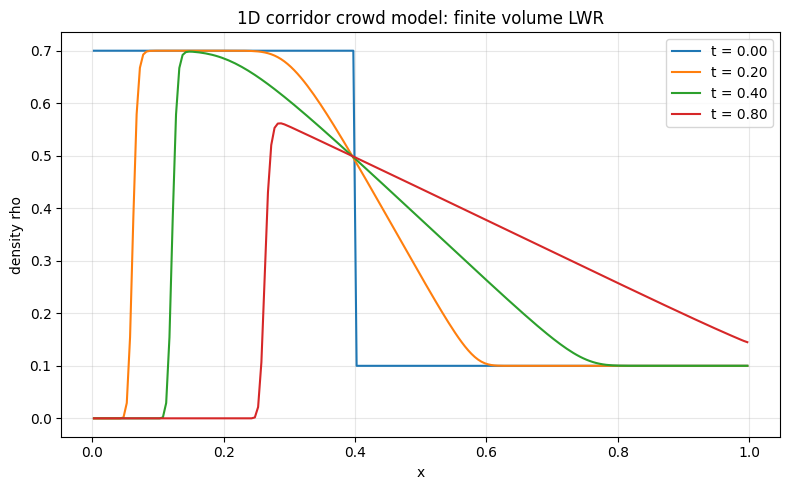

In [2]:
# Model: rho_t + (f(rho))_x = 0,  x in [0,1]
# Flux: f(rho) = rho * (1 - rho)

def flux(rho):
    """Physical flux"""
    return rho * (1.0 - rho)

def lax_friedrichs_flux(rho_L, rho_R, alpha=1.0):
    """ First part averages physical flux form right and left and second aprt adds numerical diffusion
    α <= maximum wave speed of the PDE, ∣f′(ρ)∣≤1 so chose α=1
    """
    return 0.5 * (flux(rho_L) + flux(rho_R)) - 0.5 * alpha * (rho_R - rho_L)

def initial_condition(x):
    """
    Example initial condition:
    """
    rho0 = np.where(x <= 0.4, 0.7, 0.1)
    return rho0

def solve_lwr_corridor(
    Nx=200,
    T=0.8,  #Δt≤CFLΔx/alpha
    CFL=0.8,
    alpha=1.0,
    snapshots=(0.0, 0.2, 0.4, 0.8)
):
    # Grid
    x_left, x_right = 0.0, 1.0
    dx = (x_right - x_left) / Nx
    x_centers = np.linspace(x_left + 0.5 * dx, x_right - 0.5 * dx, Nx) #FV method so we want average density in each cell

    #Fill corridor with initial density proile
    rho = initial_condition(x_centers).copy()

    # Time step from CFL
    dt = CFL * dx / alpha
    Nt = int(np.ceil(T / dt))
    dt = T / Nt

    # Snapshot storage
    snapshot_times = sorted(set(snapshots))
    saved = {0.0: rho.copy()}
    t = 0.0

    for n in range(Nt):
        # Ghost cells:
        # left boundary: no inflow after t=0  -> empty reservoir outside
        # right boundary: free outflow        -> copy last value
        rho_ext = np.zeros(Nx + 2)
        rho_ext[1:-1] = rho

        rho_ext[0] = 0.0
        rho_ext[-1] = rho[-1]

        F = np.zeros(Nx + 1)
        for j in range(Nx + 1):
            F[j] = lax_friedrichs_flux(rho_ext[j], rho_ext[j + 1], alpha=alpha)

        rho = rho - (dt / dx) * (F[1:] - F[:-1])
        rho = np.clip(rho, 0.0, 1.0)

        t += dt
        for ts in snapshot_times:
            if ts not in saved and t >= ts - 1e-12:
                saved[ts] = rho.copy()

    return x_centers, saved

x, saved = solve_lwr_corridor()

plt.figure(figsize=(8, 5))
for ts, rho_ts in saved.items():
    plt.plot(x, rho_ts, label=f"t = {ts:.2f}")

plt.xlabel("x")
plt.ylabel("density rho")
plt.title("1D corridor crowd model: finite volume LWR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Schock type test

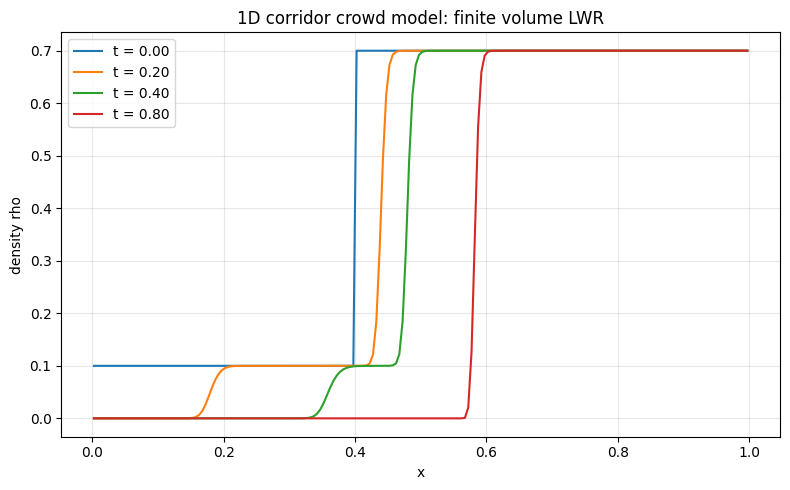

In [3]:
def initial_condition(x):
    """
    Example initial condition:
    """
    rho0 = np.where(x <= 0.4, 0.1, 0.7)
    return rho0

x, saved = solve_lwr_corridor()

plt.figure(figsize=(8, 5))
for ts, rho_ts in saved.items():
    plt.plot(x, rho_ts, label=f"t = {ts:.2f}")

plt.xlabel("x")
plt.ylabel("density rho")
plt.title("1D corridor crowd model: finite volume LWR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

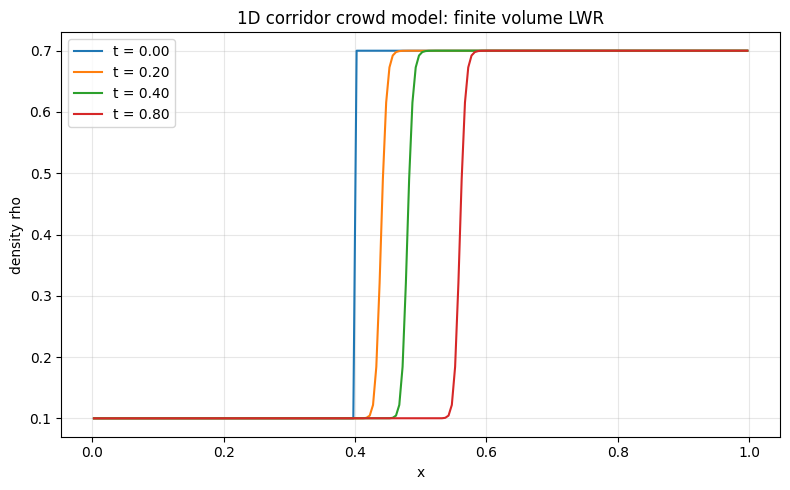

In [4]:
def solve_lwr_corridor(
    Nx=200,
    T=0.8,  #Δt≤CFLΔx/alpha
    CFL=0.8,
    alpha=1.0,
    snapshots=(0.0, 0.2, 0.4, 0.8)
):
    # Grid
    x_left, x_right = 0.0, 1.0
    dx = (x_right - x_left) / Nx
    x_centers = np.linspace(x_left + 0.5 * dx, x_right - 0.5 * dx, Nx) #FV method so we want average density in each cell

    #Fill corridor with initial density proile
    rho = initial_condition(x_centers).copy()

    # Time step from CFL
    dt = CFL * dx / alpha
    Nt = int(np.ceil(T / dt))
    dt = T / Nt

    # Snapshot storage
    snapshot_times = sorted(set(snapshots))
    saved = {0.0: rho.copy()}
    t = 0.0

    for n in range(Nt):
        # Ghost cells:
        # left boundary: no inflow after t=0  -> empty reservoir outside
        # right boundary: free outflow        -> copy last value
        rho_ext = np.zeros(Nx + 2)
        rho_ext[1:-1] = rho

        rho_ext[0] = 0.1
        rho_ext[-1] = 0.7

        F = np.zeros(Nx + 1)
        for j in range(Nx + 1):
            F[j] = lax_friedrichs_flux(rho_ext[j], rho_ext[j + 1], alpha=alpha)

        rho = rho - (dt / dx) * (F[1:] - F[:-1])
        rho = np.clip(rho, 0.0, 1.0)

        t += dt
        for ts in snapshot_times:
            if ts not in saved and t >= ts - 1e-12:
                saved[ts] = rho.copy()

    return x_centers, saved

x, saved = solve_lwr_corridor()

plt.figure(figsize=(8, 5))
for ts, rho_ts in saved.items():
    plt.plot(x, rho_ts, label=f"t = {ts:.2f}")

plt.xlabel("x")
plt.ylabel("density rho")
plt.title("1D corridor crowd model: finite volume LWR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()